# Инициализация и применение моделей машинного обучения для облаков точек в MMDetection3D

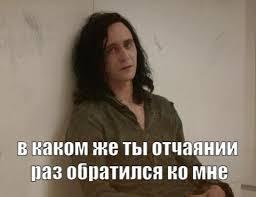

## 1. Назначение экосистемы и роль MMDetection3D

OpenMMLab — это семейство модульных фреймворков для задач компьютерного зрения. MMDetection3D ориентирован на 3D-детекцию и 3D-сегментацию на данных лидара, монокулярных и стерео изображений, а также на мультисенсорный фьюжн. Фреймворк предоставляет воспроизводимые рецепты, модульную архитектуру моделей, унифицированные конвейеры подготовки данных и единый формат конфигураций.

Типовые сценарии применения MMDetection3D:

* сравнение архитектур на стандартных датасетах;
* перенос предварительно обученных моделей на собственные данные;
* воспроизводимые эксперименты с контролируемыми модификациями компонентов модели и конвейера.

---

## 2. Установка и совместимость

Установка производится в отдельное виртуальное окружение. Порядок логически следующий: совместимая версия PyTorch с поддержкой CUDA, затем MMCV и MMEngine, затем MMDetection и MMDetection3D, после чего дополнительные зависимости для визуализации и логирования. Критически важно согласовать версии PyTorch и MMCV с версиями MMDetection3D согласно таблицам совместимости релизов. Несогласованные версии приводят к ошибкам компиляции расширений, несовместимости операторов и падениям при импорте.

---

## 3. Базовая структура проекта

* configs — рецепты и ваши производные конфигурации.
* data — исходные данные и аннотации либо симлинки на них.
* work_dirs — результаты экспериментов: логи, чекпоинты, метрики, визуализации.
* пользовательские каталоги

  * configs/*base* — собственные базовые шаблоны для наследования;
  * configs/experiments — конечные конфигурации экспериментов.

---

## 4. Конфигурации: принципы, структура, объединение

Конфигурации реализованы как Python-словарь, описанный в файле конфигурации. Система конфигов использует наследование от одного или нескольких базовых файлов через специальный ключ `_base_`. Объединение происходит по правилам рекурсивного слияния словарей.

Ключевые особенности:

* конфигурация — иерархический словарь, в котором вложенные разделы соответствуют компонентам пайплайна;
* `_base_` задает список путей к базовым конфигам, от которых наследуется текущий;
* при слиянии словарей значения в дочернем конфигурационном файле переопределяют значения родительского на соответствующих ключах;
* списки по умолчанию конкатенируются, но могут быть заменены целиком с помощью служебного ключа `_delete_=True` в дочернем разделе;
* для перекрытия сложных структур используется точечное переопределение только необходимых полей, остальное наследуется;
* конфигурации допускают определение областей имен для реестров компонентов через `default_scope` и динамический импорт пользовательских модулей через `custom_imports`.

Итоговый эффективный конфиг вычисляется после применения всех уровней `_base_`, рекурсивного объединения словарей и учета служебных ключей управления слиянием.

---

## 5. Типовая топология конфигурации

Ниже перечислены основные верхнеуровневые разделы конфигурации и их назначение. На практике они часто вынесены в отдельные базовые файлы и собираются через `_base_`.

* model
  Описание архитектуры и ее параметров. Как правило, содержит:

  * data_preprocessor — нормализация, приведение к формату, политика паддинга;
  * backbone — экстрактор признаков;
  * neck — иерархическое объединение признаков, например FPN или BiFPN;
  * head — выходные головы, функции потерь, постобработка;
  * train_cfg и test_cfg — параметры процедур обучения и инференса уровня головы и постобработки.

* train_dataloader, val_dataloader, test_dataloader
  Источники данных, самplers, коллатор, размер батча, число воркеров. Включают ссылки на датасет, который описан в блоках ниже.

* train_pipeline, test_pipeline
  Последовательности преобразований. Для 3D-задач сюда входят загрузка облаков точек или калиброванных изображений, вокселизация, генерация таргетов, аугментации в 3D-пространстве, нормализация и формирование входов модели.

* datasets или вложенные descriptions в dataloader
  Параметры датасетов: корневые каталоги, списки сплитов, формат аннотаций, метаинформация.

* metainfo
  Семантика классов задачи. Перечень классов должен соответствовать аннотациям и используется при расчете метрик и визуализации.

* optim_wrapper
  Оптимизатор и его параметры, политика градиентной аккумуляции, настройка смешанной точности.

* param_scheduler
  Расписание изменения скорости обучения и моментов. Может состоять из нескольких стадий, применяемых последовательно или по интервалам итераций.

* default_hooks
  Системные обработчики: сохранение чекпоинтов, логирование, визуализация, проверка валидности, тайминг.

* env, launcher, randomness
  Настройки окружения, детерминизм, стратегии распределенного запуска.

* visualizer, log_processor, log_level
  Отображение результатов и параметры агрегирования логов.

* default_scope, custom_imports
  Область имен реестров и динамическая загрузка пользовательских модулей.

---

## 6. Правила объединения и переопределения

* Словари объединяются рекурсивно. Поля дочернего конфигурационного файла при совпадении ключей имеют приоритет над родительскими.
* Списки по умолчанию объединяются конкатенацией. Для замены списка целиком применяют служебный ключ `_delete_=True` внутри соответствующего списка или его родительского словаря.
* Параметры, отсутствующие в дочернем файле, наследуются неизменными из базового.
* При наличии нескольких файлов в `_base_` их объединение происходит последовательно сверху вниз, после чего применяются переопределения дочернего файла.
* Вложенные структуры train_cfg и test_cfg неявно связаны с конкретными реализациями головы и постобработки, поэтому изменение типа головы требует согласованного обновления этих секций.

---

## 7. Датасеты и форматы

MMDetection3D поддерживает стандартные наборы данных, включая KITTI, nuScenes, Waymo, SemanticKITTI, ScanNet и другие. Для пользовательских данных применяются два подхода:

* приведение аннотаций к одному из поддерживаемых форматов;
* реализация собственного адаптера датасета и регистрация его в реестре компонентов с указанием в конфигурации.

Ключевые элементы корректной интеграции:

* согласованный список классов в metainfo;
* корректная геометрия сенсоров, калибровка и единицы измерения;
* соответствие конвейера данным конкретного типа, например различающиеся ветви для облаков точек и изображений.

---

## 8. Конвейеры преобразований

Преобразования задаются в виде последовательности операций, каждая из которых параметризуется. В 3D-задачах это включает:

* загрузку облаков точек и аннотаций;
* фильтрацию по дальности и плотности;
* вокселизацию или построение псевдоснимков;
* аугментации в 3D-пространстве и изображениях с учетом калибровки;
* формирование целевых структур таргетов, совместимых с выбранной головой.

Согласованность конвейера с моделью обязательна. Несоответствие приводит к ошибкам формата таргетов и недостоверным метрикам.

---

## 9. Обучение, оценка, инференс

* обучение
  Используется train_dataloader, train_pipeline и optim_wrapper. Результаты сохраняются в work_dirs с регулярными чекпоинтами и логами.
* оценка
  Проводится на валидационном или тестовом датасете с фиксированным test_pipeline. Метрики вычисляются соответствующим оценщиком и записываются в логи.
* инференс
  Выполняется с обученным чекпоинтом и test_pipeline, формируя предсказания в формате, совместимом с визуализатором и экспортерами.

---

## 10. Логирование, хуки, визуализация

* default_hooks управляют частотой сохранений, форматированием логов, синхронизацией и визуализацией.
* внешние интеграции подключаются через соответствующие визуализаторы и лог-адаптеры.
* при долгих экспериментах рекомендуется консервативная частота сохранений и периодическая валидация для контроля деградации.

---

## 11. Распределенный запуск и воспроизводимость

* запуск на нескольких устройствах регулируется полями launcher и env;
* фиксация генераторов случайных чисел задается через randomness и детерминистские опции библиотек нижнего уровня;
* для сравнимости результатов фиксируются версии зависимостей и конфигураций, включая конвейеры подготовок данных.

---

## 12. Типичные ошибки и способы диагностики

* несовместимость версий PyTorch, MMCV, MMDetection3D — проверяется по таблице совместимости;
* несогласованные классы между metainfo и аннотациями — проявляется в некорректных метриках или падениях при вычислении;
* несоответствие конвейера типу данных — приводит к ошибкам формата входов или таргетов;
* слишком маленький эффективный размер батча без аккумуляции — нестабильные градиенты и колебания метрик;
* чрезмерные аугментации в 3D — ухудшение сходимости из-за разрушения структуры сцены.

---

## 13. Минимальный алгоритм применения

1. выбрать базовый рецепт из каталога configs, соответствующий задаче и типу данных;
2. создать производный конфиг с `_base_`, указать собственные пути к данным и корректный список классов в metainfo;
3. согласовать train_pipeline и test_pipeline с типом входных данных и выбранной моделью;
4. настроить optim_wrapper и param_scheduler в соответствии с ресурсами и длительностью обучения;
5. запустить обучение, контролировать метрики валидации, сохранять контрольные чекпоинты;
6. выполнить оценку на тестовом сплите и зафиксировать конфигурацию, версии и результаты в work_dirs.

---


### HW pipline

```bash
#!/bin/bash
# Установка MMDetection3D и прогон двух версий:
#   1) PointPillars  -> KITTI   (3D object detection)
#   2) PointNet++    -> ScanNet (3D semantic segmentation)

set -euo pipefail

DEVICE="${DEVICE:-cuda:0}"

# --- venv ---
python -m venv .mmdet3d
source .mmdet3d/bin/activate
pip install --upgrade pip

# --- core deps ---
pip install "numpy<2.0"
pip install torch==2.0.1 torchvision==0.15.2 \
    --index-url https://download.pytorch.org/whl/cu118
pip install mmcv==2.1.0 \
    -f https://download.openmmlab.com/mmcv/dist/cu118/torch2.0/index.html

pip install -U openmim
mim install mmengine
mim install "mmdet>=3.0.0,<3.3.0"

# --- mmdet3d из исходников ---
if [ ! -d "mmdetection3d" ]; then
  git clone https://github.com/open-mmlab/mmdetection3d.git
fi
cd mmdetection3d
pip install -v -e .

# --- sanity check ---
python -c "import torch, mmcv, mmdet, mmdet3d; \
print(f'Torch {torch.__version__}, MMCV {mmcv.__version__}, MMDet {mmdet.__version__}, MMDet3D {mmdet3d.__version__}')"

mkdir -p checkpoints outputs


# VERSION 1: PointPillars @ KITTI (detection)
mim download mmdet3d \
  --config pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car \
  --dest checkpoints

KITTI_CKPT=$(ls checkpoints/hv_pointpillars_secfpn_*kitti-3d-car*.pth 2>/dev/null | head -n1)
if [ -z "$KITTI_CKPT" ]; then
  echo "KITTI checkpoint не найден в checkpoints/" >&2
  exit 1
fi
echo "Using KITTI checkpoint: $KITTI_CKPT"

python demo/pcd_demo.py \
  demo/data/kitti/000008.bin \
  configs/pointpillars/pointpillars_hv_secfpn_8xb6-160e_kitti-3d-car.py \
  "$KITTI_CKPT" \
  --device "$DEVICE" \
  --out-dir outputs/kitti_pointpillars


# VERSION 2: PointNet++ @ ScanNet (segmentation)
mim download mmdet3d \
  --config pointnet2_ssg_2xb16-cosine-200e_scannet-seg \
  --dest checkpoints

SCANNET_CKPT=$(ls checkpoints/pointnet2_ssg_*scannet*.pth 2>/dev/null | head -n1)
if [ -z "$SCANNET_CKPT" ]; then
  echo "ScanNet checkpoint не найден в checkpoints/" >&2
  exit 1
fi
echo "Using ScanNet checkpoint: $SCANNET_CKPT"

python demo/pcd_seg_demo.py \
  demo/data/scannet/scene0000_00.bin \
  configs/pointnet2/pointnet2_ssg_2xb16-cosine-200e_scannet-seg.py \
  "$SCANNET_CKPT" \
  --device "$DEVICE" \
  --out-dir outputs/scannet_pointnet2

echo
echo "Готово. Визуализации:"
echo "  mmdetection3d/outputs/kitti_pointpillars/"
echo "  mmdetection3d/outputs/scannet_pointnet2/"

```

Визуализация на kitty:

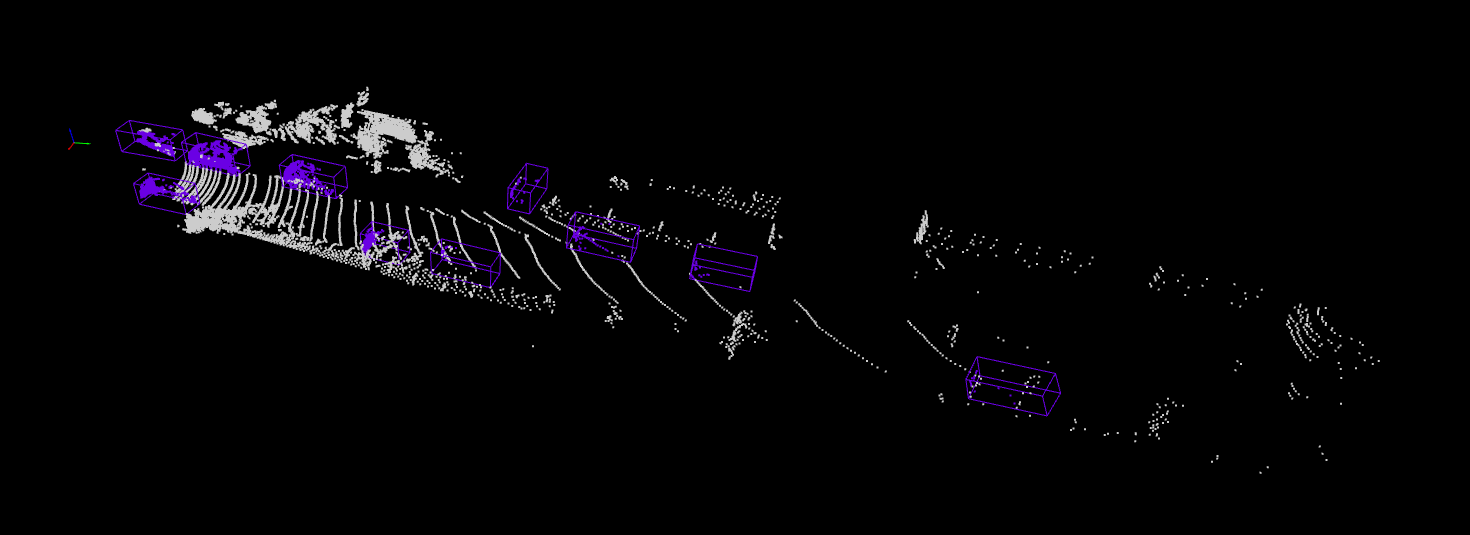

```